In [1]:
import requests
import datetime
import pandas as pd

from evidently import Report
from evidently.presets import DataDriftPreset,DataSummaryPreset
from joblib import load,dump
from tqdm import tqdm

from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score


In [2]:
files=[("green_tripdata_2022-02.parquet","./data"),("green_tripdata_2022-01.parquet","./data")]

print("Downloading files...")
for file,path in files:
    url=f"https://d37ci6vzurychx.cloudfront.net/trip-data/{file}"
    r=requests.get(url,stream=True)
    save_path=f"{path}/{file}" 
    with open(save_path,"wb") as f:
        for data in tqdm(r.iter_content(),desc=f"{file}",postfix=f"save to {save_path}",total=int(r.headers["Content-Length"])):
            f.write(data)

green_tripdata_2022-01.parquet: 100%|██████████| 1254291/1254291 [00:06<00:00, 181576.13it/s, save to ./data/green_tripdata_2022-01.parquet]


In [3]:
jan_data=pd.read_parquet("./data/green_tripdata_2022-01.parquet")

In [4]:
jan_data.describe()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
count,62495.000000,62495,62495,56200.000000,62495.000000,62495.000000,56200.000000,62495.000000,62495.000000,62495.00000,62495.000000,62495.000000,62495.000000,62495.000000,62495.000000,56200.000000,56200.000000,56200.000000
mean,1.849508,2022-01-16 14:18:36.026354,2022-01-16 14:37:37.189551,1.198719,97.615041,135.969902,1.258399,77.758632,13.914000,0.34756,0.426322,1.666540,0.208182,0.297312,17.490532,1.403594,1.040925,0.706628
min,1.000000,2009-01-01 00:34:01,2009-01-01 17:05:20,1.000000,1.000000,1.000000,0.000000,0.000000,-65.000000,-4.50000,-0.500000,-0.860000,-6.550000,-0.300000,-71.850000,1.000000,1.000000,0.000000
25%,2.000000,2022-01-08 23:41:50,2022-01-08 23:55:28.500000,1.000000,55.000000,74.000000,1.000000,1.080000,7.000000,0.00000,0.500000,0.000000,0.000000,0.300000,9.360000,1.000000,1.000000,0.000000
50%,2.000000,2022-01-16 15:59:42,2022-01-16 16:17:00,1.000000,75.000000,137.000000,1.000000,1.900000,10.500000,0.00000,0.500000,1.000000,0.000000,0.300000,13.860000,1.000000,1.000000,0.000000
75%,2.000000,2022-01-24 09:16:50,2022-01-24 09:37:28,1.000000,130.000000,215.000000,1.000000,3.500000,17.000000,0.50000,0.500000,2.610000,0.000000,0.300000,21.050000,2.000000,1.000000,2.750000
max,2.000000,2022-01-31 23:57:37,2022-02-01 21:01:54,5.000000,265.000000,265.000000,8.000000,224481.380000,604.500000,4.50000,0.500000,76.770000,44.750000,0.300000,605.300000,5.000000,2.000000,2.750000
std,0.357556,NaN,NaN,0.862313,62.987311,77.590956,0.877743,2909.354163,12.088819,0.65781,0.181381,2.484928,1.257659,0.037201,13.623416,0.516316,0.198119,1.201632


In [5]:
jan_data["duration_min"]=jan_data["lpep_dropoff_datetime"]-jan_data["lpep_pickup_datetime"]
jan_data["duration_min"]=jan_data["duration_min"].dt.total_seconds()/60

In [6]:
jan_data=jan_data[(jan_data["duration_min"]>=1)&(jan_data["duration_min"]<=60)]
jan_data=jan_data[(jan_data["passenger_count"]>=1)&(jan_data["passenger_count"]<=6)]

<Axes: >

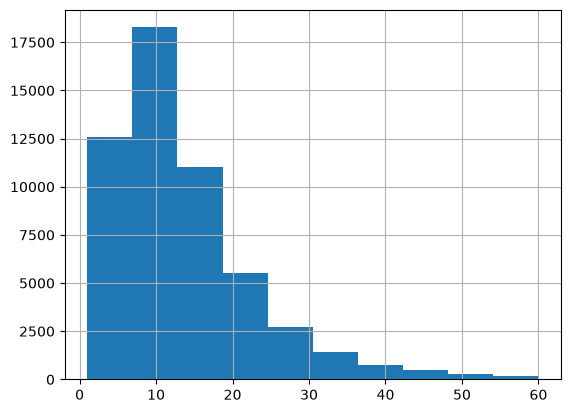

In [7]:
jan_data["duration_min"].hist()

In [8]:
target="duration_min"
numeric_features=["passenger_count","trip_distance","fare_amount","total_amount"]
categorical_features=["PULocationID","DOLocationID"]

In [9]:
train_data=jan_data[:30000]
val_data=jan_data[30000:]

In [10]:
model=LinearRegression()

In [11]:
model.fit(train_data[numeric_features+categorical_features],train_data[target])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[-0.01,-0. , 0.78,-0.01,-0. , 0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['passenger_count','trip_distance','fare_amount','total_amount', 'PULocationID','DOLocationID']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.357
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)


In [12]:
train_preds=model.predict(train_data[numeric_features+categorical_features])
train_data["preds"]=train_preds

In [13]:
val_preds=model.predict(val_data[numeric_features+categorical_features])
val_data["preds"]=val_preds

In [14]:
print(f"Train RMSE: {root_mean_squared_error(train_data[target],train_data['preds'])}")
print(f"Train R2: {r2_score(train_data[target],train_data['preds'])}")
print(f"Val RMSE: {root_mean_squared_error(val_data[target],val_data['preds'])}")
print(f"Val R2: {r2_score(val_data[target],val_data['preds'])}")

Train RMSE: 5.118346220558759
Train R2: 0.6720796991195155
Val RMSE: 5.443467128324683
Val R2: 0.6669257428188147


In [15]:
with open("models/lin_reg.bin","wb") as f_out:
    dump(model,f_out)

In [16]:
val_data.to_parquet("data/reference.parquet")

In [17]:
report=Report(
    metrics=[
        DataDriftPreset(),
        DataSummaryPreset()
    ]
)
snapshot=report.run(
    current_data=val_data,
    reference_data=train_data
)

In [18]:
snapshot.save_html("evidently_report.html")

In [19]:
result=snapshot.dict()

In [20]:
result

{'metrics': [{'id': '15e89f895b482f9b84ba7274ed18a106',
   'metric_name': 'DriftedColumnsCount(drift_share=0.5)',
   'config': {'type': 'evidently:metric_v2:DriftedColumnsCount',
    'drift_share': 0.5},
   'value': {'count': 1.0, 'share': 0.05263157894736842}},
  {'id': 'a9c9d7eb164a642cffced3edc2837c13',
   'metric_name': 'ValueDrift(column=RatecodeID,method=Jensen-Shannon distance,threshold=0.1)',
   'config': {'type': 'evidently:metric_v2:ValueDrift',
    'column': 'RatecodeID',
    'method': 'Jensen-Shannon distance',
    'threshold': 0.1},
   'value': np.float64(0.0027892202530823943)},
  {'id': '55ac0d3ab973e295b757b905344717f8',
   'metric_name': 'ValueDrift(column=PULocationID,method=Wasserstein distance (normed),threshold=0.1)',
   'config': {'type': 'evidently:metric_v2:ValueDrift',
    'column': 'PULocationID',
    'method': 'Wasserstein distance (normed)',
    'threshold': 0.1},
   'value': np.float64(0.03681032926709219)},
  {'id': '4982f3e54d389610ea57eac0b6f86a8d',
   '

In [26]:
result["metrics"][0]["value"]["count"]

1.0

In [ ]:
for m in result["metrics"]:
    if "pred" in m["metric_name"].lower():
        print(m["metric_name"], m["value"])

DatasetMissingValueCount()
{'count': 23203.0, 'share': 1.0}
MissingValueCount(column=VendorID)
{'count': 0.0, 'share': np.float64(0.0)}
MissingValueCount(column=store_and_fwd_flag)
{'count': 0.0, 'share': np.float64(0.0)}
MissingValueCount(column=RatecodeID)
{'count': 0.0, 'share': np.float64(0.0)}
MissingValueCount(column=PULocationID)
{'count': 0.0, 'share': np.float64(0.0)}
MissingValueCount(column=DOLocationID)
{'count': 0.0, 'share': np.float64(0.0)}
MissingValueCount(column=passenger_count)
{'count': 0.0, 'share': np.float64(0.0)}
MissingValueCount(column=trip_distance)
{'count': 0.0, 'share': np.float64(0.0)}
MissingValueCount(column=fare_amount)
{'count': 0.0, 'share': np.float64(0.0)}
MissingValueCount(column=extra)
{'count': 0.0, 'share': np.float64(0.0)}
MissingValueCount(column=mta_tax)
{'count': 0.0, 'share': np.float64(0.0)}
MissingValueCount(column=tip_amount)
{'count': 0.0, 'share': np.float64(0.0)}
MissingValueCount(column=tolls_amount)
{'count': 0.0, 'share': np.float